In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
raw_dir = Path("../data/raw")

nav_files = list(raw_dir.glob("*nav_history*.csv"))

print("NAV files found:", nav_files)

nav_df = pd.read_csv(nav_files[0])

print("Shape:", nav_df.shape)
print("Columns:", nav_df.columns.tolist())
print(nav_df.head())

NAV files found: [WindowsPath('../data/raw/1788499983331-4389156d-02_nav_history.csv')]
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

print("Daily returns calculated!")
print("Total rows:", len(nav_df))
print("Missing returns:", nav_df["daily_return"].isna().sum())

Daily returns calculated!
Total rows: 46000
Missing returns: 40


In [4]:
var_cvar_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    var_95 = returns.quantile(0.05)

    tail_returns = returns[returns <= var_95]

    cvar_95 = tail_returns.mean()

    var_cvar_results.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar_df = pd.DataFrame(var_cvar_results)

print("VaR & CVaR calculated!")
print("Number of schemes:", len(var_cvar_df))
print()
print(var_cvar_df.head())

VaR & CVaR calculated!
Number of schemes: 40

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [5]:
output_dir = Path("../reports")
output_dir.mkdir(parents=True, exist_ok=True)

var_cvar_file = output_dir / "var_cvar_report.csv"

var_cvar_df.to_csv(var_cvar_file, index=False)

print("VaR/CVaR report saved successfully!")
print("File:", var_cvar_file)
print("Rows:", len(var_cvar_df))

VaR/CVaR report saved successfully!
File: ..\reports\var_cvar_report.csv
Rows: 40


In [6]:
key_funds = {
    119551: "SBI Bluechip",
    120503: "ICICI Prudential Bluechip",
    118632: "Nippon India Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

print("Key funds selected:", len(key_funds))
print(key_funds)

Key funds selected: 5
{119551: 'SBI Bluechip', 120503: 'ICICI Prudential Bluechip', 118632: 'Nippon India Large Cap', 119092: 'Axis Bluechip', 120841: 'Kotak Bluechip'}


In [7]:
annual_rf = 0.065
daily_rf = (1 + annual_rf) ** (1 / 252) - 1

rolling_sharpe_data = []

for amfi_code, fund_name in key_funds.items():
    fund_data = nav_df[nav_df["amfi_code"] == amfi_code].copy()
    
    returns = fund_data["daily_return"]
    
    rolling_mean = returns.rolling(90).mean()
    rolling_std = returns.rolling(90).std()
    
    rolling_sharpe = ((rolling_mean - daily_rf) / rolling_std) * np.sqrt(252)
    
    temp = pd.DataFrame({
        "date": fund_data["date"].values,
        "amfi_code": amfi_code,
        "fund_name": fund_name,
        "rolling_sharpe_90d": rolling_sharpe.values
    })
    
    rolling_sharpe_data.append(temp)

rolling_sharpe_df = pd.concat(rolling_sharpe_data, ignore_index=True)

print("Rolling 90-day Sharpe calculated!")
print("Rows:", len(rolling_sharpe_df))
print("Funds:", rolling_sharpe_df["fund_name"].nunique())
print()
print(rolling_sharpe_df.head())

Rolling 90-day Sharpe calculated!
Rows: 5750
Funds: 5

        date  amfi_code     fund_name  rolling_sharpe_90d
0 2022-01-03     119551  SBI Bluechip                 NaN
1 2022-01-04     119551  SBI Bluechip                 NaN
2 2022-01-05     119551  SBI Bluechip                 NaN
3 2022-01-06     119551  SBI Bluechip                 NaN
4 2022-01-07     119551  SBI Bluechip                 NaN


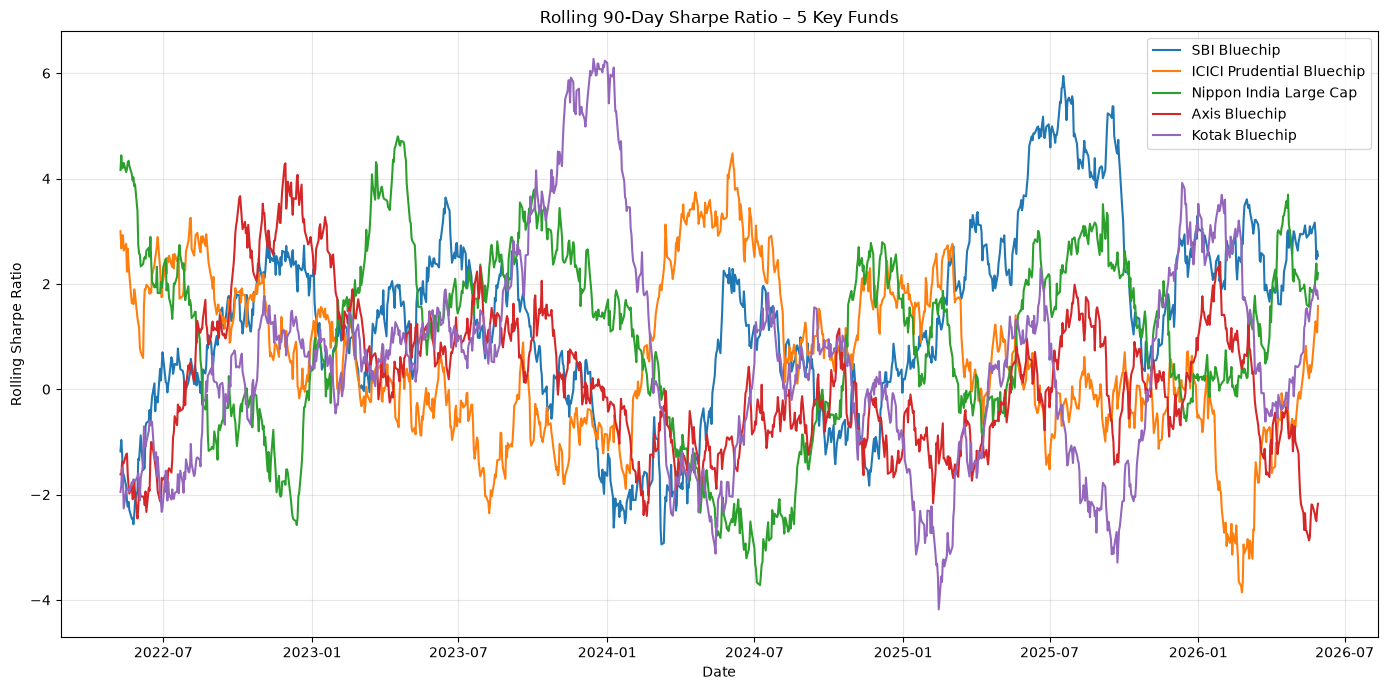

Rolling Sharpe chart saved successfully!
File: ..\reports\rolling_sharpe_chart.png


In [8]:
plt.figure(figsize=(14, 7))

for fund_name in rolling_sharpe_df["fund_name"].unique():
    data = rolling_sharpe_df[
        rolling_sharpe_df["fund_name"] == fund_name
    ]
    
    plt.plot(
        data["date"],
        data["rolling_sharpe_90d"],
        label=fund_name
    )

plt.title("Rolling 90-Day Sharpe Ratio – 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

rolling_sharpe_file = output_dir / "rolling_sharpe_chart.png"

plt.savefig(
    rolling_sharpe_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Rolling Sharpe chart saved successfully!")
print("File:", rolling_sharpe_file)

In [4]:
transaction_files = list(raw_dir.glob("*investor_transactions*.csv"))

print("Transaction files found:", transaction_files)

transactions_df = pd.read_csv(transaction_files[0])

print("Shape:", transactions_df.shape)
print("Columns:", transactions_df.columns.tolist())
print(transactions_df.head())

Transaction files found: [WindowsPath('../data/raw/1788499980509-304c1255-08_investor_transactions.csv')]
Shape: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2 

In [5]:
from pathlib import Path
import pandas as pd

raw_dir = Path("../data/raw")

print("Raw folder:", raw_dir)

Raw folder: ..\data\raw


In [6]:
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"],
    errors="coerce"
)

first_transaction = (
    transactions_df.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

transactions_df = transactions_df.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

print("Cohort year created successfully!")
print("Cohort years:", sorted(transactions_df["cohort_year"].dropna().unique()))
print(transactions_df[["investor_id", "transaction_date", "cohort_year"]].head())

Cohort year created successfully!
Cohort years: [np.int32(2024), np.int32(2025)]
  investor_id transaction_date  cohort_year
0   INV003054       2024-01-01         2024
1   INV002952       2024-01-01         2024
2   INV003420       2024-01-01         2024
3   INV003436       2024-01-01         2024
4   INV004691       2024-01-01         2024


In [7]:
# Consider SIP and Lumpsum as invested amounts
invested_df = transactions_df[
    transactions_df["transaction_type"].isin(["SIP", "Lumpsum"])
].copy()

# Average SIP amount by cohort
avg_sip = (
    transactions_df[transactions_df["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

# Total invested amount by cohort
total_invested = (
    invested_df
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_amount")
)

# Most preferred fund by each cohort
fund_preference = (
    invested_df
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    fund_preference
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
    .rename(columns={"amfi_code": "top_preferred_fund"})
)

# Combine results
cohort_summary = (
    avg_sip
    .merge(total_invested, on="cohort_year", how="outer")
    .merge(top_funds[["cohort_year", "top_preferred_fund", "transaction_count"]],
           on="cohort_year", how="left")
)

print("Investor cohort analysis completed!")
print()
print(cohort_summary)

Investor cohort analysis completed!

   cohort_year  avg_sip_amount  total_invested_amount  top_preferred_fund  \
0         2024    10996.885825             2258062304              125498   
1         2025    13505.209581               18992635              119599   

   transaction_count  
0                752  
1                 11  


In [8]:
fund_master_files = list(raw_dir.glob("*fund_master*.csv"))

print("Fund master files found:", fund_master_files)

fund_master_df = pd.read_csv(fund_master_files[0])

print("Fund master shape:", fund_master_df.shape)
print("Columns:", fund_master_df.columns.tolist())

Fund master files found: [WindowsPath('../data/raw/1788499983024-b042c300-01_fund_master.csv')]
Fund master shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [1]:
fund_lookup = fund_master_df[
    ["amfi_code", "scheme_name", "fund_house"]
].drop_duplicates("amfi_code")

cohort_summary = cohort_summary.merge(
    fund_lookup,
    left_on="top_preferred_fund",
    right_on="amfi_code",
    how="left"
)

cohort_summary = cohort_summary[
    [
        "cohort_year",
        "avg_sip_amount",
        "total_invested_amount",
        "top_preferred_fund",
        "scheme_name",
        "fund_house",
        "transaction_count"
    ]
]

print("Final cohort summary:")
print(cohort_summary)

NameError: name 'fund_master_df' is not defined

In [2]:
from pathlib import Path
import pandas as pd

raw_dir = Path("../data/raw")

# Load investor transactions
transaction_file = list(raw_dir.glob("*investor_transactions*.csv"))[0]
transactions_df = pd.read_csv(transaction_file)

# Load fund master
fund_master_file = list(raw_dir.glob("*fund_master*.csv"))[0]
fund_master_df = pd.read_csv(fund_master_file)

# Convert transaction date
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"],
    errors="coerce"
)

# Find first transaction year for each investor
first_transaction = (
    transactions_df.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

# Add cohort year
transactions_df = transactions_df.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

# Invested transactions
invested_df = transactions_df[
    transactions_df["transaction_type"].isin(["SIP", "Lumpsum"])
].copy()

# Average SIP amount
avg_sip = (
    transactions_df[
        transactions_df["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

# Total invested amount
total_invested = (
    invested_df
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_amount")
)

# Preferred fund
fund_preference = (
    invested_df
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    fund_preference
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
    .rename(columns={"amfi_code": "top_preferred_fund"})
)

# Combine cohort results
cohort_summary = (
    avg_sip
    .merge(total_invested, on="cohort_year", how="outer")
    .merge(
        top_funds[
            ["cohort_year", "top_preferred_fund", "transaction_count"]
        ],
        on="cohort_year",
        how="left"
    )
)

# Add fund name and fund house
fund_lookup = fund_master_df[
    ["amfi_code", "scheme_name", "fund_house"]
].drop_duplicates("amfi_code")

cohort_summary = cohort_summary.merge(
    fund_lookup,
    left_on="top_preferred_fund",
    right_on="amfi_code",
    how="left"
)

cohort_summary = cohort_summary[
    [
        "cohort_year",
        "avg_sip_amount",
        "total_invested_amount",
        "top_preferred_fund",
        "scheme_name",
        "fund_house",
        "transaction_count"
    ]
]

print("Final cohort analysis completed!")
print(cohort_summary)

Final cohort analysis completed!
   cohort_year  avg_sip_amount  total_invested_amount  top_preferred_fund  \
0         2024    10996.885825             2258062304              125498   
1         2025    13505.209581               18992635              119599   

                                         scheme_name        fund_house  \
0  HDFC Mid-Cap Opportunities Fund - Direct - Growth  HDFC Mutual Fund   
1          SBI Small Cap Fund - Direct Plan - Growth   SBI Mutual Fund   

   transaction_count  
0                752  
1                 11  


In [4]:
sip_df = transactions_df[
    transactions_df["transaction_type"] == "SIP"
].copy()

sip_df["month"] = sip_df["transaction_date"].dt.to_period("M")

sip_monthly = (
    sip_df
    .groupby(["investor_id", "month"])
    .size()
    .reset_index(name="sip_count")
)

print("SIP monthly activity created!")
print("Unique SIP investors:", sip_monthly["investor_id"].nunique())
print("Monthly records:", len(sip_monthly))
print(sip_monthly.head())

SIP monthly activity created!
Unique SIP investors: 4762
Monthly records: 17347
  investor_id    month  sip_count
0   INV000001  2024-11          1
1   INV000001  2025-01          1
2   INV000002  2024-03          1
3   INV000002  2024-09          1
4   INV000002  2025-05          1


In [5]:
# Number of active SIP months for each investor
investor_sip_months = (
    sip_monthly
    .groupby("investor_id")["month"]
    .nunique()
    .reset_index(name="active_sip_months")
)

# Classify SIP continuity
def classify_continuity(months):
    if months >= 12:
        return "Continuous (12+ months)"
    elif months >= 6:
        return "Regular (6-11 months)"
    elif months >= 3:
        return "Occasional (3-5 months)"
    else:
        return "Short-term (1-2 months)"

investor_sip_months["continuity_group"] = (
    investor_sip_months["active_sip_months"]
    .apply(classify_continuity)
)

# Summary
continuity_summary = (
    investor_sip_months["continuity_group"]
    .value_counts()
    .reset_index()
)

continuity_summary.columns = ["continuity_group", "investor_count"]

continuity_summary["percentage"] = (
    continuity_summary["investor_count"]
    / continuity_summary["investor_count"].sum()
    * 100
)

print("SIP continuity analysis completed!")
print(continuity_summary)

SIP continuity analysis completed!
          continuity_group  investor_count  percentage
0  Occasional (3-5 months)            2336   49.055019
1  Short-term (1-2 months)            1549   32.528349
2    Regular (6-11 months)             877   18.416632


In [6]:
# Calculate SIP tenure for each investor
sip_tenure = (
    sip_monthly
    .groupby("investor_id")["month"]
    .agg(
        first_sip_month="min",
        last_sip_month="max",
        active_sip_months="nunique"
    )
    .reset_index()
)

# Calendar tenure: first SIP month to last SIP month
sip_tenure["tenure_months"] = (
    (sip_tenure["last_sip_month"].dt.year -
     sip_tenure["first_sip_month"].dt.year) * 12
    +
    (sip_tenure["last_sip_month"].dt.month -
     sip_tenure["first_sip_month"].dt.month) + 1
)

# Investors who continued SIP for at least 2 consecutive months
sip_monthly_sorted = sip_monthly.sort_values(["investor_id", "month"]).copy()

sip_monthly_sorted["next_month"] = (
    sip_monthly_sorted
    .groupby("investor_id")["month"]
    .shift(-1)
)

sip_monthly_sorted["consecutive"] = (
    sip_monthly_sorted["next_month"]
    == sip_monthly_sorted["month"] + 1
)

retained_investors = (
    sip_monthly_sorted
    .groupby("investor_id")["consecutive"]
    .any()
    .sum()
)

total_sip_investors = sip_tenure["investor_id"].nunique()

retention_rate = (
    retained_investors / total_sip_investors * 100
)

average_tenure = sip_tenure["tenure_months"].mean()
average_active_months = sip_tenure["active_sip_months"].mean()

print("SIP Continuity Metrics")
print("----------------------")
print("Total SIP investors:", total_sip_investors)
print("Investors with consecutive SIP months:", retained_investors)
print("Retention rate:", round(retention_rate, 2), "%")
print("Average SIP tenure:", round(average_tenure, 2), "months")
print("Average active SIP months:", round(average_active_months, 2), "months")

SIP Continuity Metrics
----------------------
Total SIP investors: 4762
Investors with consecutive SIP months: 2212
Retention rate: 46.45 %
Average SIP tenure: 9.54 months
Average active SIP months: 3.64 months


In [7]:
# Load fund master data

fund_master_files = list(raw_dir.glob("*fund_master*.csv"))

print("Fund master files found:", fund_master_files)

fund_master_df = pd.read_csv(fund_master_files[0])

print("Shape:", fund_master_df.shape)
print("Columns:", fund_master_df.columns.tolist())
print(fund_master_df[[
    "amfi_code",
    "scheme_name",
    "category",
    "min_sip_amount",
    "min_lumpsum_amount",
    "risk_category"
]].head(10))

Fund master files found: [WindowsPath('../data/raw/1788499983024-b042c300-01_fund_master.csv')]
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
   amfi_code                                        scheme_name category  \
0     119551          SBI Bluechip Fund - Regular Plan - Growth   Equity   
1     119552           SBI Bluechip Fund - Direct Plan - Growth   Equity   
2     119598         SBI Small Cap Fund - Regular Plan - Growth   Equity   
3     119599          SBI Small Cap Fund - Direct Plan - Growth   Equity   
4     119120       SBI Magnum Gilt Fund - Regular Plan - Growth     Debt   
5     100016          HDFC Top 100 Fund - Regular Plan - Growth   Equity   
6     125497           HDFC Top 100 Fund - Direct Plan - Growth   Equity   
7     100033  HDFC Mid-Cap Oppo

In [8]:
def recommend_schemes(age, risk_profile, investment_amount, top_n=3):
    """
    Recommend top schemes based on age, risk profile and investment amount.
    """

    df = fund_master_df.copy()

    # Risk profile match
    risk_profile = risk_profile.strip().title()

    df = df[df["risk_category"] == risk_profile].copy()

    # Investment amount eligibility
    df = df[
        df["min_lumpsum_amount"] <= investment_amount
    ].copy()

    # If no schemes match, return empty result
    if df.empty:
        return pd.DataFrame(
            columns=[
                "amfi_code",
                "scheme_name",
                "category",
                "risk_category",
                "min_lumpsum_amount"
            ]
        )

    # Simple age-based preference
    if age < 30:
        preferred_categories = ["Equity"]
    elif age < 50:
        preferred_categories = ["Equity", "Hybrid"]
    else:
        preferred_categories = ["Debt", "Hybrid", "Equity"]

    # Give preference to suitable categories
    df["category_score"] = df["category"].apply(
        lambda x: 2 if x in preferred_categories else 1
    )

    # Sort by suitability
    df = df.sort_values(
        ["category_score", "expense_ratio_pct"],
        ascending=[False, True]
    )

    return df[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "risk_category",
            "min_lumpsum_amount"
        ]
    ].head(top_n)

In [9]:
recommendations = recommend_schemes(
    age=25,
    risk_profile="Moderate",
    investment_amount=10000
)

print("Top 3 Recommended Schemes:")
print(recommendations)

Top 3 Recommended Schemes:
    amfi_code                                    scheme_name category  \
1      119552       SBI Bluechip Fund - Direct Plan - Growth   Equity   
16     118633  Nippon India Large Cap Fund - Direct - Growth   Equity   
25     119093           Axis Bluechip Fund - Direct - Growth   Equity   

   risk_category  min_lumpsum_amount  
1       Moderate                1000  
16      Moderate                1000  
25      Moderate                1000  


In [1]:
portfolio_files = list(raw_dir.glob("*portfolio_holdings*.csv"))

print("Portfolio holdings files found:", portfolio_files)

portfolio_df = pd.read_csv(portfolio_files[0])

print("Shape:", portfolio_df.shape)
print("Columns:", portfolio_df.columns.tolist())
print(portfolio_df.head())

NameError: name 'raw_dir' is not defined

In [2]:
from pathlib import Path
import pandas as pd

raw_dir = Path("../data/raw")

print("Raw folder:", raw_dir)

Raw folder: ..\data\raw


In [3]:
portfolio_files = list(raw_dir.glob("*portfolio_holdings*.csv"))

print("Portfolio holdings files found:", portfolio_files)

portfolio_df = pd.read_csv(portfolio_files[0])

print("Shape:", portfolio_df.shape)
print("Columns:", portfolio_df.columns.tolist())
print(portfolio_df.head())

Portfolio holdings files found: [WindowsPath('../data/raw/1788499982117-e3d6ab98-09_portfolio_holdings.csv')]
Shape: (322, 8)
Columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82 

In [4]:
# Calculate aggregate sector weights

sector_weights = (
    portfolio_df
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index(name="aggregate_weight_pct")
)

# Convert aggregate weights into proportions
total_weight = sector_weights["aggregate_weight_pct"].sum()

sector_weights["sector_share"] = (
    sector_weights["aggregate_weight_pct"] / total_weight
)

# Calculate HHI contribution
sector_weights["hhi_contribution"] = (
    sector_weights["sector_share"] ** 2
)

# Overall HHI
sector_hhi = sector_weights["hhi_contribution"].sum()

# Concentration flag
concentration_flag = (
    "High Concentration"
    if sector_hhi > 0.25
    else "Normal Concentration"
)

print("Sector HHI Analysis")
print("-------------------")
print("Overall HHI:", round(sector_hhi, 4))
print("Concentration:", concentration_flag)

print("\nSector-wise weights:")
print(
    sector_weights
    .sort_values("aggregate_weight_pct", ascending=False)
    .to_string(index=False)
)

Sector HHI Analysis
-------------------
Overall HHI: 0.1018
Concentration: Normal Concentration

Sector-wise weights:
        sector  aggregate_weight_pct  sector_share  hhi_contribution
       Banking                652.26      0.191842          0.036803
            IT                455.47      0.133962          0.017946
        Pharma                407.45      0.119839          0.014361
    Automobile                323.65      0.095191          0.009061
     Utilities                265.54      0.078100          0.006100
          FMCG                229.11      0.067385          0.004541
Infrastructure                192.16      0.056518          0.003194
   Diversified                169.23      0.049774          0.002477
       Telecom                145.62      0.042830          0.001834
Consumer Goods                127.61      0.037532          0.001409
          NBFC                119.09      0.035027          0.001227
        Energy                117.91      0.034680    

## Key Advanced Analytics Insights

1. **Market Risk:** The VaR and CVaR analysis shows that extreme daily losses can be higher than the normal 95% loss level. This helps identify the downside risk of each fund.

2. **SIP Continuity:** Out of 4,762 SIP investors, 2,212 investors continued their SIP in consecutive months. The calculated retention rate was 46.45%.

3. **SIP Investment Behaviour:** The average SIP tenure was 9.54 months, but investors were actively investing for an average of only 3.64 months. This shows that many investors did not continue their SIP regularly.

4. **Sector Concentration:** The overall sector HHI was 0.1018, which is below the 0.25 high-concentration level. This indicates that the portfolio holdings are reasonably diversified across sectors.

5. **Fund Recommendation:** A simple rule-based recommender was created using age, risk profile and investment amount. It filters suitable funds and provides the top 3 scheme recommendations for an investor.